In [1]:
import os
while not os.path.isdir('.git'):
    os.chdir('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import matplotlib as mpl
mpl.rcParams["font.family"] = "Avenir"

# Random Poisson inputs

In [2]:
idxs = np.arange(0, 20)

In [3]:
conditions = {
    "No TI": "subthreshold_conductance/random_poisson/5/noTI_0.1",
    "5 Hz": "subthreshold_conductance/random_poisson/5/1000_5_0.9_0.1",
    "130 Hz": "subthreshold_conductance/random_poisson/5/1000_130_0.9_0.1",
    "0 Hz": "subthreshold_conductance/random_poisson/5/1000_0_0.25_0.1"
}

colors = {
    "No TI": "tab:blue",
    "5 Hz": "tab:orange",
    "130 Hz": "tab:green",
    "0 Hz": "tab:red"
}

## Data in a single run

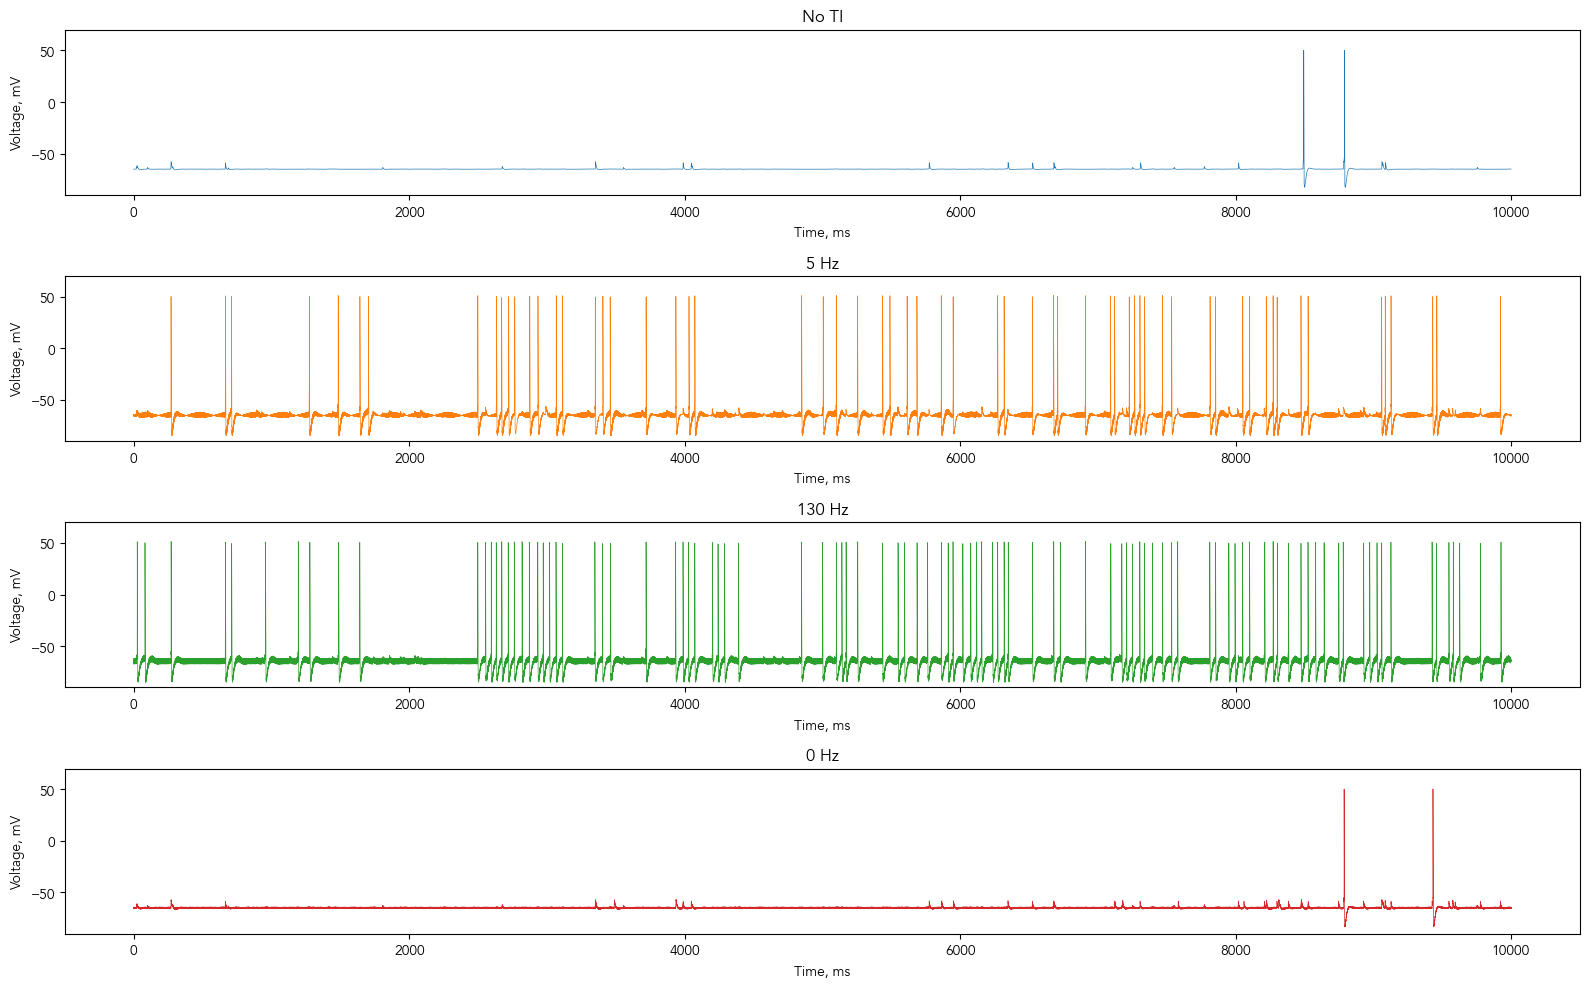

In [4]:
fig, axs = plt.subplots(nrows = len(conditions), ncols = 1, figsize = (16, 2.5 * len(conditions)))

idx = 0

for condition, ax in zip(conditions.keys(), axs):
    filename = conditions[condition]
    color = colors[condition]

    voltage = pd.read_csv(f"output/temporal-interference/{idx}/{filename}/voltage.csv")

    ax.plot(
        voltage.Time,
        voltage.Voltage,
        linewidth = 0.5,
        color = color
    )

    ax.set_xlabel("Time, ms")
    ax.set_ylabel("Voltage, mV")
    ax.set_ylim(-90, 70)

    ax.set_title(condition)

fig.tight_layout()
plt.show()

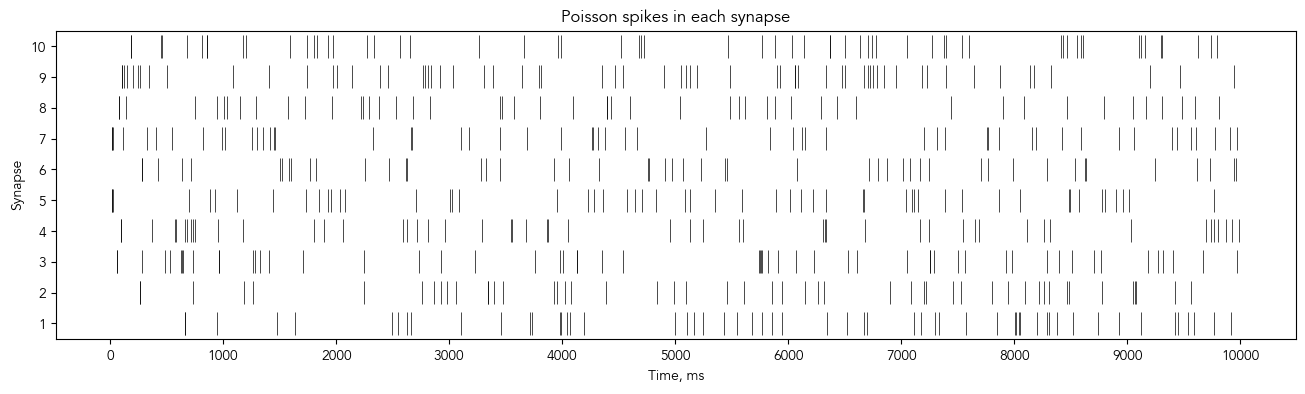

In [5]:
spike_times = pd.read_csv(f"output/temporal-interference/{idx}/{conditions['No TI']}/synapse_stimuli.csv", header=None)
spike_times = spike_times.fillna('').values.tolist()
spike_times = [[x for x in row if x != ""] for row in spike_times]

plt.figure(figsize = (16, 4))

for i, spikes in enumerate(spike_times):
    plt.eventplot(spikes, lineoffsets = i + 1, linelengths = 0.75, colors = "black", linewidths = 0.5)

plt.ylim(0.5, 10.5)
plt.ylabel("Synapse")
plt.yticks(np.arange(1, 11, 1))

plt.xlabel("Time, ms")
plt.xticks(np.arange(0, 10_000 + 1000, 1000))

plt.title("Poisson spikes in each synapse")
plt.show()

In [6]:
def expand_time(original, max_time = 10_000):
    original["Time"] = (original["Time"] / 0.025).round() * 0.025
    original = original.sort_values("Time")

    new_time = np.arange(0, max_time + 0.025, 0.025)

    expanded = pd.DataFrame({ "Time": new_time })
    expanded = pd.merge_asof(expanded, original, on = "Time", direction = "backward")

    return expanded

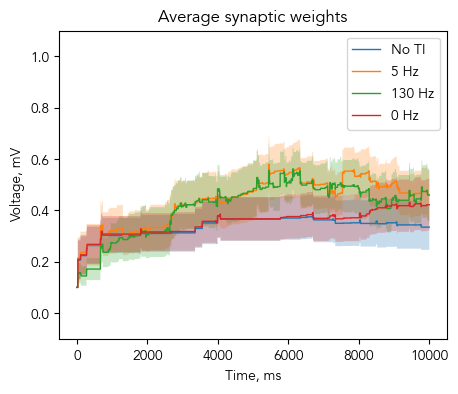

In [7]:
plt.figure(figsize = (5, 4))

for condition in conditions.keys():
    filename = conditions[condition]
    color = colors[condition]

    weights = pd.read_csv(f"output/temporal-interference/{idx}/{filename}/synapse_weights.csv")
    weights = expand_time(weights)
    time = weights.Time
    weights = np.array([ weights[f"Synapse{i}"] for i in range(0, 10) ])

    mean = weights.mean(axis = 0)
    error = weights.std(axis = 0) / np.sqrt(weights.shape[0])

    plt.plot(
        time,
        mean,
        linewidth = 1,
        label = condition
    )
    plt.fill_between(
        time, mean - error, mean + error,
        alpha = 0.25
    )

    plt.xlabel("Time, ms")
    plt.ylabel("Voltage, mV")
    plt.ylim(-0.1, 1.1)

    plt.title("Average synaptic weights")

plt.legend()

fig.tight_layout()
plt.show()

## Data in 20 runs

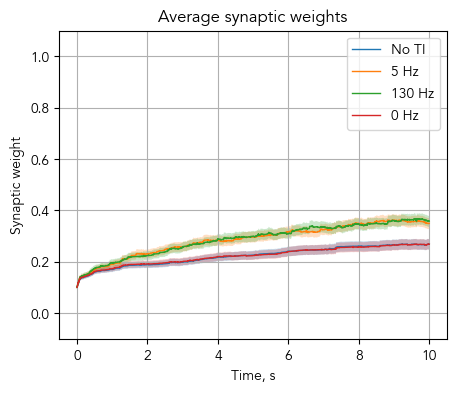

In [8]:
plt.figure(figsize = (5, 4))

for condition in conditions.keys():
    filename = conditions[condition]
    color = colors[condition]

    weights = []
    time = []
    
    for idx in idxs:
        synapse_weights = pd.read_csv(f"output/temporal-interference/{idx}/{filename}/synapse_weights.csv")
        synapse_weights = expand_time(synapse_weights)
        time = synapse_weights.Time / 1000
        
        synapse_weights = np.array([ synapse_weights[f"Synapse{i}"] for i in range(0, 10) ])
        weights.append(synapse_weights)

    weights = np.concatenate(weights)

    mean = weights.mean(axis = 0)
    error = weights.std(axis = 0)  / np.sqrt(weights.shape[0])

    plt.plot(
        time,
        mean,
        linewidth = 1,
        label = condition
    )
    plt.fill_between(
        time, mean - error, mean + error,
        alpha = 0.25
    )

    plt.xlabel("Time, s")
    plt.ylabel("Synaptic weight")
    plt.ylim(-0.1, 1.1)

    plt.title("Average synaptic weights")

plt.legend()
plt.grid(True)

fig.tight_layout()
plt.show()

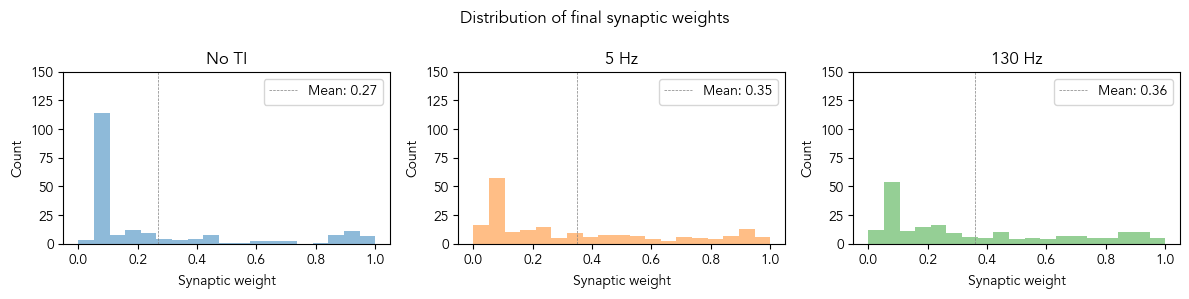

In [9]:
fig, axs = plt.subplots(nrows = 1, ncols = 3, figsize = (12, 3))

for condition, ax in zip(conditions.keys(), axs):
    filename = conditions[condition]
    color = colors[condition]

    weights = []

    for idx in idxs:
        synapse_weights = pd.read_csv(f"output/temporal-interference/{idx}/{filename}/synapse_weights.csv")
        synapse_weights = np.array([ synapse_weights.iloc[-1][f"Synapse{i}"] for i in range(0, 10) ])
        weights.append(synapse_weights)

    weights = np.concatenate(weights)

    bin_edges = np.linspace(0, 1, num = 20)
    ax.hist(weights, bins = bin_edges, alpha = 0.5, color = color)
    ax.axvline(weights.mean(), linewidth = 0.5, color = "gray", linestyle = "--", label = f"Mean: {round(weights.mean(), 2)}")
    ax.set_title(condition)
    ax.set_ylim(0, 150)
    ax.legend()
    ax.set_ylabel("Count")
    ax.set_xlabel("Synaptic weight")

fig.suptitle("Distribution of final synaptic weights")
fig.tight_layout()
plt.show()

## 10 Hz

In [10]:
idxs = np.arange(10, 20)

conditions = {
    "No TI": "subthreshold_conductance/random_poisson/10/noTI_0.1",
    "5 Hz": "subthreshold_conductance/random_poisson/10/1000_5_0.9_0.1",
    "130 Hz": "subthreshold_conductance/random_poisson/10/1000_130_0.9_0.1"
}

colors = {
    "No TI": "tab:blue",
    "5 Hz": "tab:orange",
    "130 Hz": "tab:green"
}

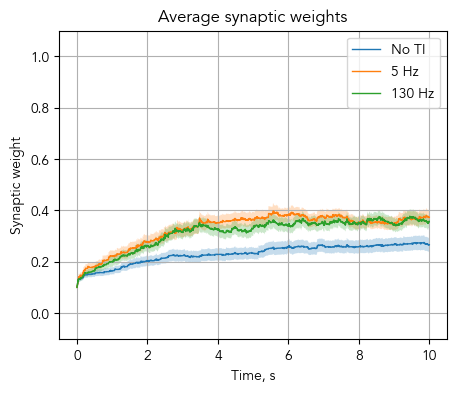

In [11]:
plt.figure(figsize = (5, 4))

for condition in conditions.keys():
    filename = conditions[condition]
    color = colors[condition]

    weights = []
    time = []

    for idx in idxs:
        synapse_weights = pd.read_csv(f"output/temporal-interference/{idx}/{filename}/synapse_weights.csv")
        synapse_weights = expand_time(synapse_weights)
        time = synapse_weights.Time / 1000

        synapse_weights = np.array([ synapse_weights[f"Synapse{i}"] for i in range(0, 10) ])
        weights.append(synapse_weights)

    weights = np.concatenate(weights)

    mean = weights.mean(axis = 0)
    error = weights.std(axis = 0)  / np.sqrt(weights.shape[0])

    plt.plot(
        time,
        mean,
        linewidth = 1,
        label = condition
    )
    plt.fill_between(
        time, mean - error, mean + error,
        alpha = 0.25
    )

    plt.xlabel("Time, s")
    plt.ylabel("Synaptic weight")
    plt.ylim(-0.1, 1.1)

    plt.title("Average synaptic weights")

plt.legend()
plt.grid(True)

fig.tight_layout()
plt.show()

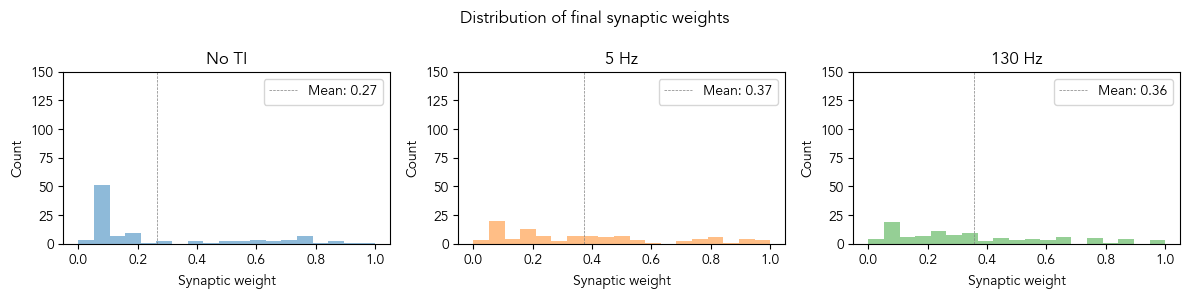

In [12]:
fig, axs = plt.subplots(nrows = 1, ncols = 3, figsize = (12, 3))

for condition, ax in zip(conditions.keys(), axs):
    filename = conditions[condition]
    color = colors[condition]

    weights = []

    for idx in idxs:
        synapse_weights = pd.read_csv(f"output/temporal-interference/{idx}/{filename}/synapse_weights.csv")
        synapse_weights = np.array([ synapse_weights.iloc[-1][f"Synapse{i}"] for i in range(0, 10) ])
        weights.append(synapse_weights)

    weights = np.concatenate(weights)

    bin_edges = np.linspace(0, 1, num = 20)
    ax.hist(weights, bins = bin_edges, alpha = 0.5, color = color)
    ax.axvline(weights.mean(), linewidth = 0.5, color = "gray", linestyle = "--", label = f"Mean: {round(weights.mean(), 2)}")
    ax.set_title(condition)
    ax.set_ylim(0, 150)
    ax.legend()
    ax.set_ylabel("Count")
    ax.set_xlabel("Synaptic weight")

fig.suptitle("Distribution of final synaptic weights")
fig.tight_layout()
plt.show()

## 40 Hz

In [13]:
idxs = np.arange(10, 20)

conditions = {
    "No TI": "subthreshold_conductance/random_poisson/40/noTI_0.1",
    "5 Hz": "subthreshold_conductance/random_poisson/40/1000_5_0.9_0.1",
    "130 Hz": "subthreshold_conductance/random_poisson/40/1000_130_0.9_0.1"
}

colors = {
    "No TI": "tab:blue",
    "5 Hz": "tab:orange",
    "130 Hz": "tab:green"
}

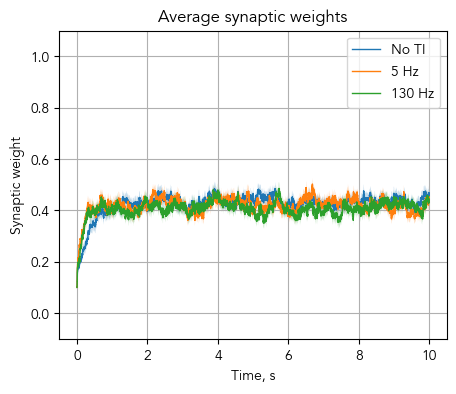

In [14]:
plt.figure(figsize = (5, 4))

for condition in conditions.keys():
    filename = conditions[condition]
    color = colors[condition]

    weights = []
    time = []

    for idx in idxs:
        synapse_weights = pd.read_csv(f"output/temporal-interference/{idx}/{filename}/synapse_weights.csv")
        synapse_weights = expand_time(synapse_weights)
        time = synapse_weights.Time / 1000

        synapse_weights = np.array([ synapse_weights[f"Synapse{i}"] for i in range(0, 10) ])
        weights.append(synapse_weights)

    weights = np.concatenate(weights)

    mean = weights.mean(axis = 0)
    error = weights.std(axis = 0)  / np.sqrt(weights.shape[0])

    plt.plot(
        time,
        mean,
        linewidth = 1,
        label = condition
    )
    plt.fill_between(
        time, mean - error, mean + error,
        alpha = 0.25
    )

    plt.xlabel("Time, s")
    plt.ylabel("Synaptic weight")
    plt.ylim(-0.1, 1.1)

    plt.title("Average synaptic weights")

plt.legend()
plt.grid(True)

fig.tight_layout()
plt.show()

## 80 Hz

In [15]:
idxs = np.arange(10, 20)

conditions = {
    "No TI": "subthreshold_conductance/random_poisson/80/noTI_0.1",
    "5 Hz": "subthreshold_conductance/random_poisson/80/1000_5_0.9_0.1",
    "130 Hz": "subthreshold_conductance/random_poisson/80/1000_130_0.9_0.1"
}

colors = {
    "No TI": "tab:blue",
    "5 Hz": "tab:orange",
    "130 Hz": "tab:green"
}

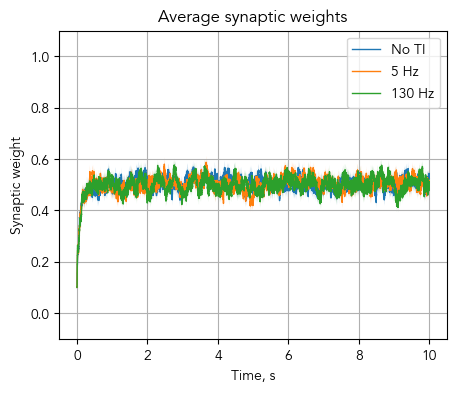

In [16]:
plt.figure(figsize = (5, 4))

for condition in conditions.keys():
    filename = conditions[condition]
    color = colors[condition]

    weights = []
    time = []

    for idx in idxs:
        synapse_weights = pd.read_csv(f"output/temporal-interference/{idx}/{filename}/synapse_weights.csv")
        synapse_weights = expand_time(synapse_weights)
        time = synapse_weights.Time / 1000

        synapse_weights = np.array([ synapse_weights[f"Synapse{i}"] for i in range(0, 10) ])
        weights.append(synapse_weights)

    weights = np.concatenate(weights)

    mean = weights.mean(axis = 0)
    error = weights.std(axis = 0)  / np.sqrt(weights.shape[0])

    plt.plot(
        time,
        mean,
        linewidth = 1,
        label = condition
    )
    plt.fill_between(
        time, mean - error, mean + error,
        alpha = 0.25
    )

    plt.xlabel("Time, s")
    plt.ylabel("Synaptic weight")
    plt.ylim(-0.1, 1.1)

    plt.title("Average synaptic weights")

plt.legend()
plt.grid(True)

fig.tight_layout()
plt.show()